# Part 2: Object Detection


## T2.1: On-Shelf Model

In [ ]:
# Mounting Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Install Ultralytics (YOLOv8)
!pip install ultralytics
# Import the YOLO class
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Unzipping the dataset (replace with your actual file path)
!unzip '/content/drive/MyDrive/Solar Panel Defects.v1i.yolov8.zip' -d '/content/solar_dataset_Detection_2'


Archive:  /content/drive/MyDrive/Solar Panel Defects.v1i.yolov8.zip
  inflating: /content/solar_dataset_Detection_2/README.dataset.txt  
  inflating: /content/solar_dataset_Detection_2/README.roboflow.txt  
  inflating: /content/solar_dataset_Detection_2/data.yaml  
   creating: /content/solar_dataset_Detection_2/test/
   creating: /content/solar_dataset_Detection_2/test/images/
 extracting: /content/solar_dataset_Detection_2/test/images/Bird-1-_jpeg.rf.08a5dd36a841d9d837bc78916c86d71d.jpg  
 extracting: /content/solar_dataset_Detection_2/test/images/Bird-100-_jpg.rf.3758f0b8660aa38f7fc7dd469e738a4d.jpg  
 extracting: /content/solar_dataset_Detection_2/test/images/Bird-105-_jpg.rf.3fa2ade5328ea3dcd627942e2c73e181.jpg  
 extracting: /content/solar_dataset_Detection_2/test/images/Bird-117-_jpg.rf.dde3c355d4c02b7e3e454c73fbbad9de.jpg  
 extracting: /content/solar_dataset_Detection_2/test/images/Bird-167-_JPG.rf.9422ae6414db98d44081bf06607888f1.jpg  
 extracting: /content/solar_dataset_Det

In [ ]:
import os
from collections import Counter

def count_classes(label_path):
    counter = Counter()
    for file in os.listdir(label_path):
        if file.endswith(".txt"):
            with open(os.path.join(label_path, file), "r") as f:
                for line in f:
                    cls_id = line.strip().split()[0]
                    counter[cls_id] += 1
    return counter

dataset_dir = '/content/solar_dataset_Detection_2'  # update this

train_labels = os.path.join(dataset_dir, "train", "labels")
val_labels   = os.path.join(dataset_dir, "valid", "labels")
test_labels  = os.path.join(dataset_dir, "test", "labels")

train_counts = count_classes(train_labels)
val_counts   = count_classes(val_labels)
test_counts  = count_classes(test_labels)

print("=== TRAIN CLASS COUNTS ===")
print(train_counts)
print("\n=== VALIDATION CLASS COUNTS ===")
print(val_counts)
print("\n=== TEST CLASS COUNTS ===")
print(test_counts)


=== TRAIN CLASS COUNTS ===
Counter({'3': 386, '0': 263, '5': 115, '7': 79, '6': 73, '1': 56, '2': 49, '4': 1})

=== VALIDATION CLASS COUNTS ===
Counter({'3': 105, '0': 78, '5': 41, '2': 25, '7': 19, '6': 12, '1': 12})

=== TEST CLASS COUNTS ===
Counter({'3': 32, '0': 31, '5': 16, '2': 13, '7': 12, '1': 9, '6': 6})


In [ ]:
model_s = YOLO("yolov8s.pt")

results = model_s.train(
    data="/content/solar_dataset_Detection_2/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    optimizer='Adam',
    lr0=0.001,
    patience=20,
    augment=True,
    project="models",
    name="YOLOv8small_OnShelf",
    exist_ok=True,
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_dataset_Detection_2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=YOLOv8small_OnShelf, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, perspec

In [ ]:
print("===== Evaluation: YOLOv8s =====")
metrics_s = model_s.val(data="/content/solar_dataset_Detection_2/data.yaml", imgsz=640)

print("\n--- YOLOv8s Results ---")
print("Precision:", metrics_s.box.mp)
print("Recall:", metrics_s.box.mr)
print("mAP@50:", metrics_s.box.map50)
print("mAP@50-95:", metrics_s.box.map)


===== Evaluation: YOLOv8s =====
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1546.7±794.8 MB/s, size: 79.7 KB)
val: Scanning /content/solar_dataset_Detection_2/valid/labels.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 378.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 5.0it/s 2.2s
                   all        169        292      0.667      0.461      0.524      0.413
                 Clean         77         78      0.791      0.729      0.815      0.735
               Electro         10         12      0.554      0.167      0.162      0.137
                  Snow         25         25       0.76      0.633      0.721      0.418
                Thermo         43        105      0.913      0.667       0.84      0

In [ ]:
print("===== Training YOLOv8n on Solar Dataset =====")

model_n = YOLO("yolov8n.pt")

results_n = model_n.train(
    data="/content/solar_dataset_Detection_2/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="Adam",
    lr0=0.001,
    patience=20,
    augment=True,
    project="models",
    name="YOLOv8nano_OnShelf",
    exist_ok=True,
)



===== Training YOLOv8n on Solar Dataset =====
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_dataset_Detection_2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=YOLOv8nano_OnShelf, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
print("===== Evaluation: YOLOv8n =====")
metrics_n = model_n.val(data="/content/solar_dataset_Detection_2/data.yaml", imgsz=640)

print("\n--- YOLOv8n Results ---")
print("Precision:", metrics_n.box.mp)
print("Recall:", metrics_n.box.mr)
print("mAP@50:", metrics_n.box.map50)
print("mAP@50-95:", metrics_n.box.map)


===== Evaluation: YOLOv8n =====
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1668.3±754.3 MB/s, size: 67.0 KB)
val: Scanning /content/solar_dataset_Detection_2/valid/labels.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 354.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 5.5it/s 2.0s
                   all        169        292      0.638      0.464      0.536      0.421
                 Clean         77         78      0.757      0.769      0.843      0.759
               Electro         10         12       0.55      0.167      0.222      0.146
                  Snow         25         25      0.848        0.6      0.656      0.457
                Thermo         43        105      0.891      0.676      0.851      0.7

In [ ]:
print("\n=================ON SHELF FINAL COMPARISON =================")
print(f"YOLOv8n  mAP@50:     {metrics_n.box.map50:.3f}")
print(f"YOLOv8s  mAP@50:     {metrics_s.box.map50:.3f}")

print(f"YOLOv8n  mAP@50-95:  {metrics_n.box.map:.3f}")
print(f"YOLOv8s  mAP@50-95:  {metrics_s.box.map:.3f}")

print(f"YOLOv8n  Precision:  {metrics_n.box.mp:.3f}")
print(f"YOLOv8s  Precision:  {metrics_s.box.mp:.3f}")

print(f"YOLOv8n  Recall:     {metrics_n.box.mr:.3f}")
print(f"YOLOv8s  Recall:     {metrics_s.box.mr:.3f}")



=================ON SHELF FINAL COMPARISON =================
YOLOv8n  mAP@50:     0.536
YOLOv8s  mAP@50:     0.524
YOLOv8n  mAP@50-95:  0.421
YOLOv8s  mAP@50-95:  0.413
YOLOv8n  Precision:  0.638
YOLOv8s  Precision:  0.667
YOLOv8n  Recall:     0.464
YOLOv8s  Recall:     0.461


## T2.2 Custom Training for Object Detection

### Expermint1: yolov8m

In [ ]:
model = YOLO("yolov8m.pt")

results = model.train(
    data="/content/solar_dataset_Detection_2/data.yaml",
    epochs=50,
    imgsz=1024,
    batch=8,
    optimizer="AdamW",
    lr0=0.002,         # higher LR → faster learning in 50 epochs
    weight_decay=0.0005,
    freeze=0,
    mixup=0.0,
    mosaic=0.3,
    fliplr=0.5,
    flipud=0.3,
    scale=0.7,
    translate=0.1,
    shear=0.1,
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.3,
    patience=30,
    project="models",
    name="YOLOv8med_custom",
    exist_ok=True,
)




Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_dataset_Detection_2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=YOLOv8med_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective

In [ ]:
print("===== Evaluating T2.2 Improved Model =====")

metrics_t22 = model.val(
    data="/content/solar_dataset_Detection_2/data.yaml",
    imgsz=1024
)

print("\n--- T2.2 yolov8m Results ---")
print("Precision:", metrics_t22.box.mp)
print("Recall:", metrics_t22.box.mr)
print("mAP@50:", metrics_t22.box.map50)
print("mAP@50-95:", metrics_t22.box.map)


===== Evaluating T2.2 Improved Model =====
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 92 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1549.1±958.5 MB/s, size: 67.0 KB)
val: Scanning /content/solar_dataset_Detection_2/valid/labels.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 370.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.7it/s 6.3s
                   all        169        292      0.541       0.37      0.407      0.298
                 Clean         77         78      0.577      0.769      0.698      0.534
               Electro         10         12          1          0     0.0329     0.0197
                  Snow         25         25      0.536       0.28      0.454      0.263
                Thermo         43        105       0.83      0.714      0

### Expermint2: Yolov8s

In [ ]:
from ultralytics import YOLO

# Load base model
model_t22 = YOLO("yolov8s.pt")

print("===== T2.2 Improved YOLOv8 with Multi-Scale =====")

results = model_t22.train(
    data="/content/solar_dataset_Detection_2/data.yaml",
    epochs=50,
    imgsz=1024,
    batch=8,

    # OPTIMIZER
    optimizer="AdamW",
    lr0=0.0015,
    weight_decay=0.0005,

    # AUGMENTATIONS
    mosaic=0.2,
    mixup=0.0,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.3,
    fliplr=0.5,
    flipud=0.2,
    scale=0.6,

    #  KEY ARCHITECTURE MODIFICATION
    multi_scale=True,     # <--- the safe architecture-level improvement

    # FULL TRAINING
    freeze=0,
    patience=25,
    verbose=True,
    project="models",
    name="YOLOv8small_custom",
    exist_ok=True,
)

# Evaluate
metrics = model_t22.val()
print("\n--- T2.2 Multi-Scale Results ---")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)



===== T2.2 Improved YOLOv8 with Multi-Scale =====
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_dataset_Detection_2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.3, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0015, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.2, multi_scale=True, name=YOLOv8small_custom, nbs=64, nms=False, opset=None, optimize=False, optimiz

## Comparison between the four models

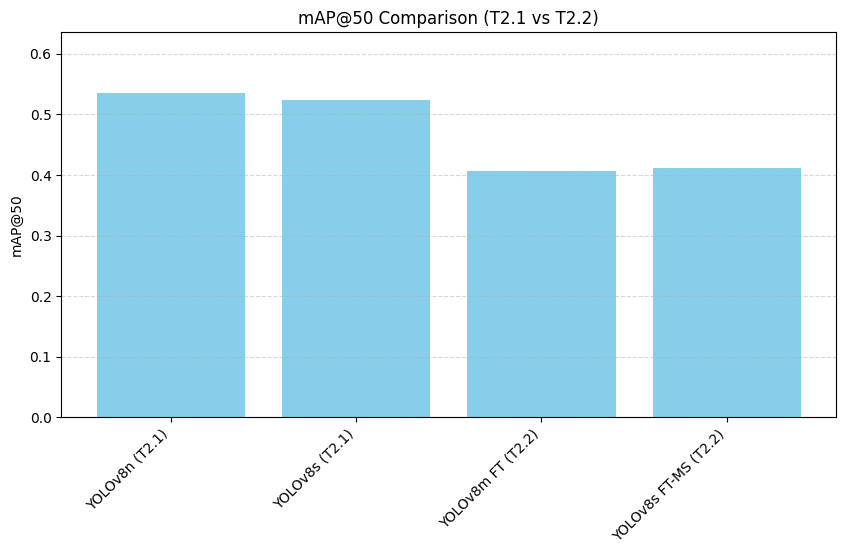

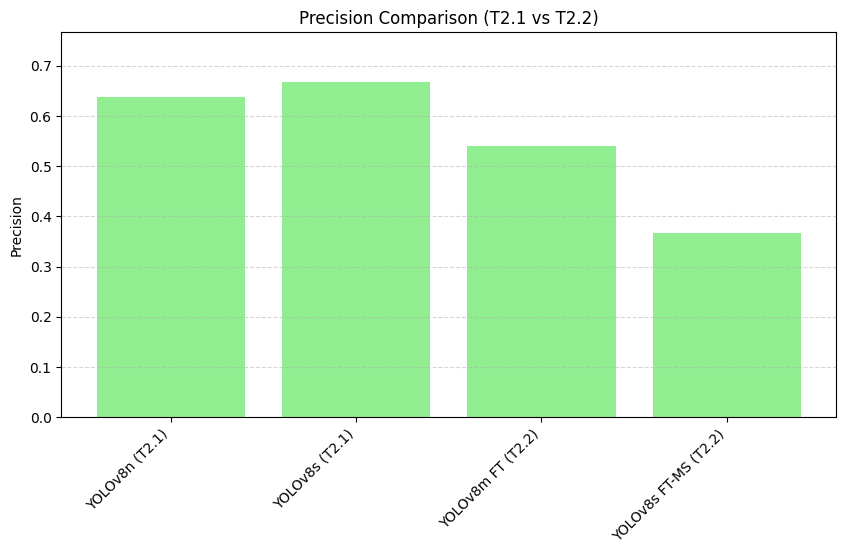

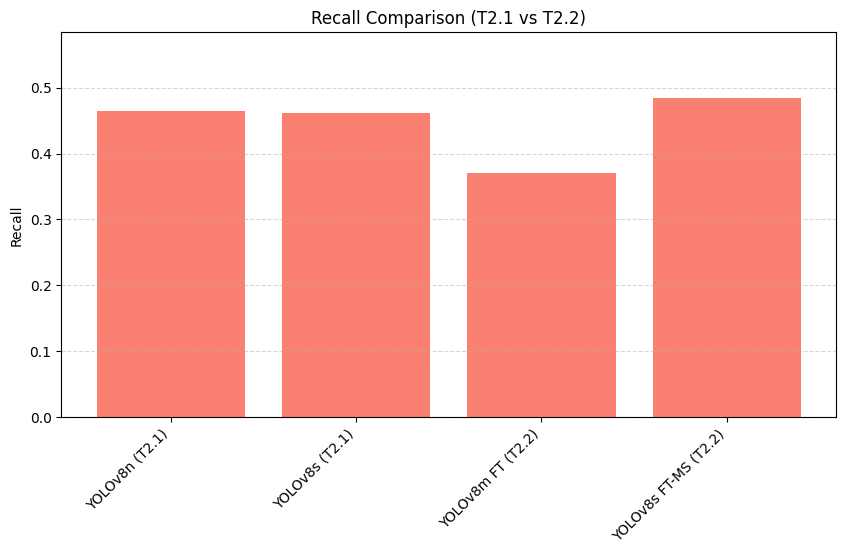

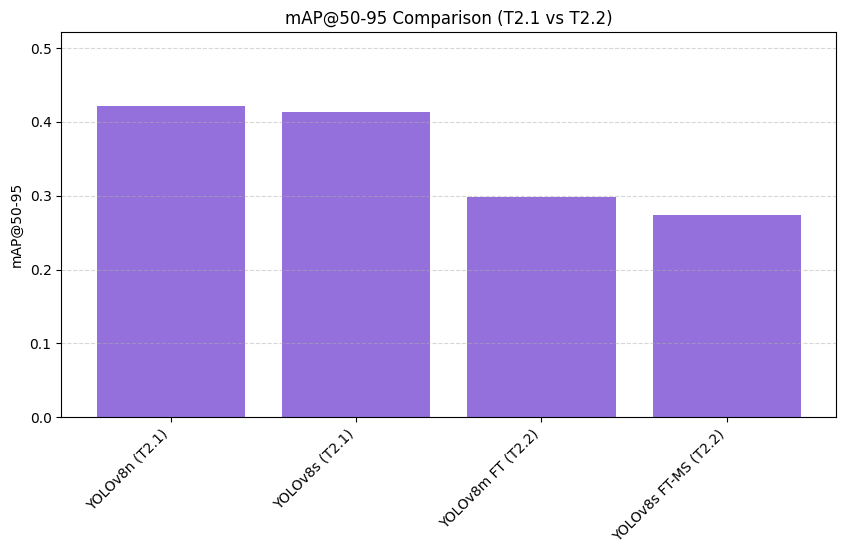

In [ ]:
# ================================================
#  FINAL METRIC GRAPHS (T2.1 vs T2.2)
# ================================================

import matplotlib.pyplot as plt

# Model labels
models = [
    "YOLOv8n (T2.1)",
    "YOLOv8s (T2.1)",
    "YOLOv8m FT (T2.2)",
    "YOLOv8s FT-MS (T2.2)",
]

# Extract metrics
precision = [
    metrics_n.box.mp,
    metrics_s.box.mp,
    metrics_t22.box.mp,
    metrics.box.mp
]

recall = [
    metrics_n.box.mr,
    metrics_s.box.mr,
    metrics_t22.box.mr,
    metrics.box.mr
]

map50 = [
    metrics_n.box.map50,
    metrics_s.box.map50,
    metrics_t22.box.map50,
    metrics.box.map50
]

map95 = [
    metrics_n.box.map,
    metrics_s.box.map,
    metrics_t22.box.map,
    metrics.box.map
]

# --------------------------------------
#  Graph 1 – mAP@50 Comparison
# --------------------------------------
plt.figure(figsize=(10,5))
plt.bar(models, map50, color='skyblue')
plt.title("mAP@50 Comparison (T2.1 vs T2.2)")
plt.ylabel("mAP@50")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(map50) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --------------------------------------
# Graph 2 – Precision Comparison
# --------------------------------------
plt.figure(figsize=(10,5))
plt.bar(models, precision, color='lightgreen')
plt.title("Precision Comparison (T2.1 vs T2.2)")
plt.ylabel("Precision")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(precision) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --------------------------------------
#  Graph 3 – Recall Comparison
# --------------------------------------
plt.figure(figsize=(10,5))
plt.bar(models, recall, color='salmon')
plt.title("Recall Comparison (T2.1 vs T2.2)")
plt.ylabel("Recall")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(recall) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --------------------------------------
#  Graph 4 – mAP@50-95 Comparison
# --------------------------------------
plt.figure(figsize=(10,5))
plt.bar(models, map95, color='mediumpurple')
plt.title("mAP@50-95 Comparison (T2.1 vs T2.2)")
plt.ylabel("mAP@50-95")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(map95) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
